# Linear Regression from Scratch

Linear regression predicts a continuous number as a weighted sum of the input features plus a
constant:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b = \sum_{j=1}^{D} w_j x_j + b$$

The weights $\mathbf{w}$ say how much each feature moves the prediction, and the intercept $b$ sets
the level when every feature is zero. Fitting the model means choosing $\mathbf{w}$ and $b$ so the
predictions sit as close as possible to the observed targets.

"As close as possible" needs a definition. The one used here is the **mean squared error**:

$$J(\mathbf{w}, b) = \frac{1}{2n} \sum_{i=1}^{n} \left( \hat{y}_i - y_i \right)^2$$

Squaring makes every error positive and punishes large misses far more than small ones. The factor
$\tfrac{1}{2}$ has no statistical meaning at all. It is there only because differentiating the
square brings a factor of 2 down, and the $\tfrac{1}{2}$ cancels it, which keeps the gradient
expressions clean. Minimising $J$ and minimising $2J$ give exactly the same parameters.

This notebook fits that model two ways on the same data: iteratively with gradient descent, and in
one shot with the closed-form normal equation. The two answers should agree, and checking that they
do is the strongest correctness test available here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue = '#2a78d6'
orange = '#eb6834'
aqua = '#1baf7a'

np.random.seed(42)

## Loading the data

`fetch_ucirepo(id=9)` downloads the Auto MPG dataset: 398 cars described by 7 numeric features,
with fuel economy in miles per gallon as the target.

`horsepower` has 6 missing values. Features and target are joined into one frame with
`pd.concat` before calling `dropna`, so that dropping a row removes its feature values *and* its
target together. Dropping them separately would shift the two arrays out of alignment and quietly
pair every car after row 32 with the wrong mpg.

In [2]:
auto = fetch_ucirepo(id=9)

frame = pd.concat([auto.data.features, auto.data.targets], axis=1)
print('rows before dropping missing:', len(frame))

frame = frame.dropna()
print('rows after:', len(frame))

feature_names = list(auto.data.features.columns)
X_all = frame[feature_names].values.astype(float)
y_all = frame['mpg'].values.astype(float)

print('features:', feature_names)
print('X:', X_all.shape, ' y:', y_all.shape)
print('mpg range: %.1f to %.1f' % (y_all.min(), y_all.max()))

rows before dropping missing: 398
rows after: 392
features: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']
X: (392, 7)  y: (392,)
mpg range: 9.0 to 46.6


The columns live on wildly different scales. The cell below prints the mean and standard deviation
of each one. `weight` runs into the thousands while `cylinders` is a single digit, and that gap is
what breaks gradient descent later unless the features are rescaled first.

In [3]:
for j, name in enumerate(feature_names):
    print('%-14s min %8.1f  max %8.1f  mean %8.2f  std %8.2f' %
          (name, X_all[:, j].min(), X_all[:, j].max(), X_all[:, j].mean(), X_all[:, j].std()))

displacement   min     68.0  max    455.0  mean   194.41  std   104.51
cylinders      min      3.0  max      8.0  mean     5.47  std     1.70
horsepower     min     46.0  max    230.0  mean   104.47  std    38.44
weight         min   1613.0  max   5140.0  mean  2977.58  std   848.32
acceleration   min      8.0  max     24.8  mean    15.54  std     2.76
model_year     min     70.0  max     82.0  mean    75.98  std     3.68
origin         min      1.0  max      3.0  mean     1.58  std     0.80


## Train/test split

The split is done by hand: `np.random.RandomState(0)` gives a generator seeded independently of the
global seed, `permutation` shuffles the row indices, and the first 80% become the training set. Any
number reported on the test rows is a number the model never saw during fitting.

In [4]:
rng = np.random.RandomState(0)
order = rng.permutation(len(X_all))

n_train = int(0.8 * len(X_all))
train_idx = order[:n_train]
test_idx = order[n_train:]

X_train_raw = X_all[train_idx]
X_test_raw = X_all[test_idx]
y_train = y_all[train_idx]
y_test = y_all[test_idx]

print('train:', X_train_raw.shape, ' test:', X_test_raw.shape)

train: (313, 7)  test: (79, 7)


## Gradient descent

There is no way to read the best $\mathbf{w}$ and $b$ straight off the data, so gradient descent
starts from zero and walks downhill on $J$. Each parameter moves against its own partial derivative.

Start from the loss and one weight $w_j$. Writing $\hat{y}_i = \sum_k w_k x_{ik} + b$,

$$\frac{\partial J}{\partial w_j}
= \frac{\partial}{\partial w_j} \; \frac{1}{2n} \sum_{i=1}^{n} \left( \hat{y}_i - y_i \right)^2
= \frac{1}{2n} \sum_{i=1}^{n} 2 \left( \hat{y}_i - y_i \right) \frac{\partial \hat{y}_i}{\partial w_j}$$

and since $\partial \hat{y}_i / \partial w_j = x_{ij}$, the 2 cancels the $\tfrac{1}{2}$ and leaves

$$\frac{\partial J}{\partial w_j} = \frac{1}{n} \sum_{i=1}^{n} \left( \hat{y}_i - y_i \right) x_{ij}$$

The intercept works the same way with $\partial \hat{y}_i / \partial b = 1$:

$$\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} \left( \hat{y}_i - y_i \right)$$

Stacking the $D$ weight derivatives into one vector turns the sum into a matrix product, which is
what the code actually computes:

$$\nabla_{\mathbf{w}} J = \frac{1}{n} X^\top \left( \hat{\mathbf{y}} - \mathbf{y} \right)$$

Every parameter then takes a step against its gradient, scaled by the learning rate $\alpha$:

$$\theta \leftarrow \theta - \alpha \nabla_{\theta} J$$

$\alpha$ trades speed against stability. Too small and the parameters creep towards the minimum and
run out of iterations before arriving. Too large and each step overshoots the bottom by more than it
started away from it, so the loss grows instead of shrinking and the run diverges. Both failures are
plotted further down.

One property makes this far easier than training a neural network: $J$ is a **convex** function of
$\mathbf{w}$ and $b$. Its Hessian is $\tfrac{1}{n} X^\top X$, which is positive semi-definite for
any $X$, so the surface is a bowl. There is a single global minimum and no local minima to get
trapped in. Given a small enough $\alpha$ and enough iterations, gradient descent from any starting
point reaches the same answer.

`Linear_Regression` below implements exactly the equations above. `fit` initialises `self.w` to
zeros and `self.b` to zero, then loops `n_iter` times: predict, take the error vector, record the
cost in `self.history`, form `dw` and `db`, and step. The `np.isfinite` check breaks the loop when
the cost has blown up to infinity, which keeps a diverging run from filling `self.history` with
`nan`.

In [5]:
class Linear_Regression:
    def __init__(self, alpha=0.01, n_iter=1000):
        self.alpha = alpha
        self.n_iter = n_iter

    def fit(self, X, y):
        n, D = X.shape
        self.w = np.zeros(D)
        self.b = 0.0
        self.history = []

        for i in range(self.n_iter):
            y_hat = X.dot(self.w) + self.b
            error = y_hat - y

            cost = np.sum(error ** 2) / (2 * n)
            self.history.append(cost)
            if not np.isfinite(cost):
                break

            # dJ/dw = (1/n) X^T (y_hat - y),  dJ/db = (1/n) sum(y_hat - y)
            dw = X.T.dot(error) / n
            db = np.sum(error) / n

            self.w = self.w - self.alpha * dw
            self.b = self.b - self.alpha * db

        self.history = np.array(self.history)
        return self

    def predict(self, X):
        return X.dot(self.w) + self.b

## Scoring a regression

Classification accuracy has no equivalent here, since a prediction of 24.3 mpg against a true 24.1
is neither right nor wrong. The standard summary is $R^2$, built from two sums of squares.

The **total sum of squares** is the error made by the laziest possible model, one that ignores every
feature and always predicts the mean $\bar{y}$:

$$SS_{tot} = \sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2$$

The **residual sum of squares** is the error the fitted model actually makes:

$$SS_{res} = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2$$

$R^2$ is the fraction of the first that the model removed:

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Read it as **the fraction of the variance in $y$ that the model accounts for**. $R^2 = 1$ means the
residuals are all zero and the fit is exact. $R^2 = 0$ means $SS_{res} = SS_{tot}$, so the model is
no better than predicting the mean. And $R^2$ **can be negative**, which surprises people who assume
the "squared" in the name bounds it below by zero. Nothing stops $SS_{res}$ from exceeding
$SS_{tot}$: a model fitted on one set of rows and scored on another can predict worse than the
constant $\bar{y}$, and then $R^2 < 0$. On training data of a least-squares fit that cannot happen,
because the mean-only model is one of the candidates least squares was choosing among, so the fit is
at least as good. On held-out data there is no such guarantee.

There is a second trap. $R^2$ on the training set **never decreases when a feature is added**, no
matter how useless the feature is. Least squares can always set the new weight to zero and recover
the old fit exactly, so the optimum can only be as good or better. Even a column of pure noise picks
up a small non-zero weight that fits some of the residual by luck. **Adjusted $R^2$** charges rent
for each feature:

$$R^2_{adj} = 1 - \left( 1 - R^2 \right) \frac{n - 1}{n - D - 1}$$

As $D$ grows the fraction grows, inflating the penalty term, so a feature has to improve the fit by
more than chance would to raise $R^2_{adj}$. That claim is tested with an actual noise column at the
end of the notebook.

Two error measures in the target's own units are also worth having:

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \hat{y}_i - y_i \right)^2}
\qquad
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| \hat{y}_i - y_i \right|$$

RMSE and MAE are both in **mpg**, so "3.4" means the typical miss is about three and a half miles
per gallon, which can be judged against the 9 to 46.6 mpg spread of the data. $R^2$ is a ratio of
two sums of squares and so is unitless, which makes it comparable across datasets but meaningless as
a physical quantity. RMSE squares before averaging and so is dragged upward by a few large misses;
MAE weights every error equally. RMSE above MAE is the normal state of affairs and the gap indicates
how much of the error is concentrated in outliers.

In [6]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


def adjusted_r_squared(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r_squared(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))

## Simple linear regression: weight alone

The single most informative column is `weight`. Heavier cars burn more fuel, so the relationship is
strong and negative, and with one feature the fitted model is a line

$$\hat{y} = w x + b$$

that can be drawn straight over the scatter.

Even with a single feature the scale matters. Raw `weight` values are in the thousands, so the
gradient $\tfrac{1}{n}\sum (\hat y_i - y_i) x_i$ is thousands of times larger than the intercept
gradient and any $\alpha$ stable enough for $w$ leaves $b$ barely moving. The fix is to standardise
the column, fit on the standardised version, and convert the coefficients back afterwards. With
$x_{std} = (x - \mu)/\sigma$,

$$\hat{y} = w\,\frac{x - \mu}{\sigma} + b = \underbrace{\frac{w}{\sigma}}_{w_{raw}} x
+ \underbrace{\left( b - \frac{w\mu}{\sigma} \right)}_{b_{raw}}$$

so the line in original units comes out of the standardised fit with two divisions. `mu_w` and
`sigma_w` are computed from the **training** column only.

In [7]:
w_col = feature_names.index('weight')

x_train_w = X_train_raw[:, [w_col]]
x_test_w = X_test_raw[:, [w_col]]

mu_w = x_train_w.mean()
sigma_w = x_train_w.std()

x_train_w_std = (x_train_w - mu_w) / sigma_w
x_test_w_std = (x_test_w - mu_w) / sigma_w

simple = Linear_Regression(alpha=0.1, n_iter=2000)
simple.fit(x_train_w_std, y_train)

# convert the standardised coefficients back to raw mpg-per-pound units
w_raw = simple.w[0] / sigma_w
b_raw = simple.b - simple.w[0] * mu_w / sigma_w

print('standardised:  w = %.4f   b = %.4f' % (simple.w[0], simple.b))
print('raw units:     w = %.6f mpg per pound   b = %.4f mpg' % (w_raw, b_raw))
print('final training cost J = %.4f' % simple.history[-1])

standardised:  w = -6.3305   b = 23.2955
raw units:     w = -0.007506 mpg per pound   b = 45.7536 mpg
final training cost J = 9.7929


The coefficient in raw units says how many mpg are lost per extra pound of car. Multiplying by 1000
gives a more readable figure. The cell below reports that alongside $R^2$, RMSE and MAE on the
training and test rows.

In [8]:
pred_train_s = simple.predict(x_train_w_std)
pred_test_s = simple.predict(x_test_w_std)

print('%.3f mpg lost per extra 1000 lb' % (-w_raw * 1000))
print()
print('              train     test')
print('R2         %8.4f %8.4f' % (r_squared(y_train, pred_train_s), r_squared(y_test, pred_test_s)))
print('RMSE mpg   %8.4f %8.4f' % (rmse(y_train, pred_train_s), rmse(y_test, pred_test_s)))
print('MAE  mpg   %8.4f %8.4f' % (mae(y_train, pred_train_s), mae(y_test, pred_test_s)))

7.506 mpg lost per extra 1000 lb

              train     test
R2           0.6717   0.7657
RMSE mpg     4.4256   3.8928
MAE  mpg     3.3562   2.9068


The test score comes out above the training score here. That is not a mistake and it is not the
model doing something clever on unseen data. With only 79 test cars, which rows land in the test
set matters, and this particular split happened to put slightly easier cars there. It is a reminder
that a single held-out score carries real uncertainty.

The plot below draws every car as a point and the fitted line across the full weight range. The line
is evaluated with `w_raw` and `b_raw`, so it is plotted in pounds rather than standardised units.

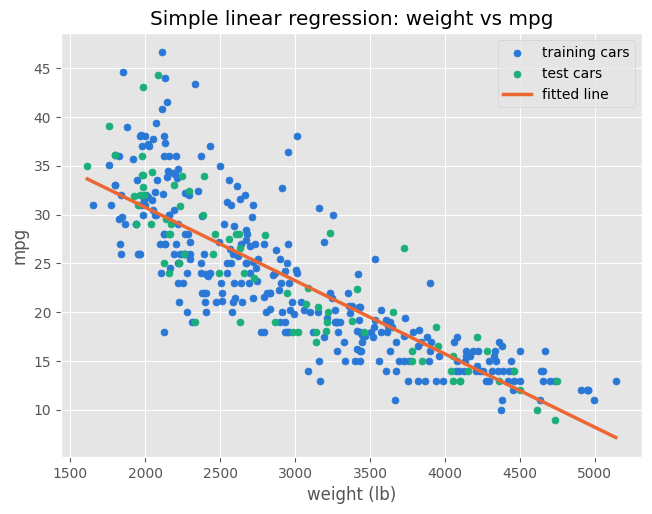

In [9]:
grid = np.linspace(X_all[:, w_col].min(), X_all[:, w_col].max(), 100)

plt.figure(figsize=(7.5, 5.5))
plt.scatter(X_train_raw[:, w_col], y_train, s=25, color=blue, label='training cars')
plt.scatter(X_test_raw[:, w_col], y_test, s=25, color=aqua, label='test cars')
plt.plot(grid, w_raw * grid + b_raw, color=orange, linewidth=2.5, label='fitted line')
plt.xlabel('weight (lb)')
plt.ylabel('mpg')
plt.title('Simple linear regression: weight vs mpg')
plt.legend()
plt.show()

`simple.history` holds the cost after every one of the 2000 iterations. Plotted on a log y-axis it
shows the usual shape: a steep drop while the parameters are far from the minimum, then a long flat
tail once they are close and the gradient has shrunk.

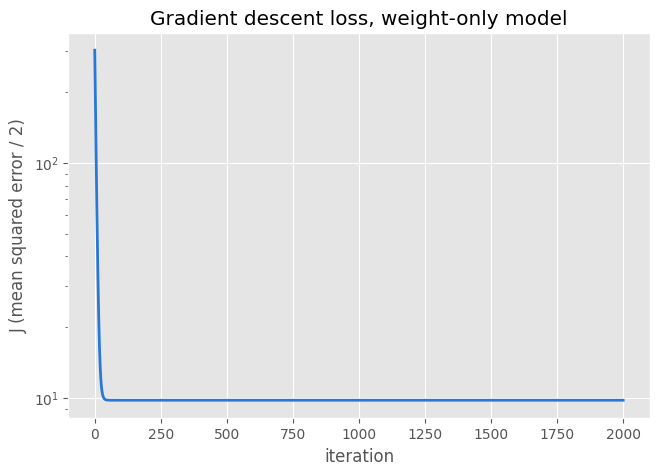

In [10]:
plt.figure(figsize=(7.5, 5))
plt.plot(simple.history, color=blue, linewidth=2)
plt.yscale('log')
plt.xlabel('iteration')
plt.ylabel('J (mean squared error / 2)')
plt.title('Gradient descent loss, weight-only model')
plt.show()

## What the learning rate does

$\alpha$ is the only knob in plain gradient descent and it decides whether the run works at all. The
cell below fits the same one-feature problem five times, changing nothing but $\alpha$, and plots
all five loss curves on shared log axes.

The step is stable only while $\alpha$ stays below $2 / \lambda_{max}$, where $\lambda_{max}$ is the
largest eigenvalue of the Hessian $\tfrac{1}{n} X^\top X$. Above that threshold each step lands
further from the minimum than it started, the error grows geometrically, and the cost runs off to
infinity within a few dozen iterations. The `np.errstate` block suppresses the overflow warnings
that the diverging run produces on its way there, and the `np.isfinite` check inside `fit` stops the
loop as soon as the cost stops being a number, which is why that curve ends early.

This particular problem has an unusually clean threshold. The design matrix is a column of ones
next to a single column with training mean 0 and standard deviation 1, so
$\tfrac{1}{n} X^\top X$ is exactly the 2x2 identity, both eigenvalues are 1, and the stability limit
is exactly $\alpha < 2$. It also means $\alpha = 1$ is the ideal step: the gradient step coincides
with the Newton step and lands on the minimum after a single iteration, which is why that curve is
flat from iteration 1 onwards. Real problems are never this well conditioned.

The y-axis is capped at $10^6$ so the four convergent curves stay readable. The $\alpha = 2.1$ curve
leaves the top of the plot after about 30 iterations and reaches $8.7 \times 10^{18}$ before the
cost overflows to infinity and the loop stops.

alpha 0.001   iterations run  200  final J 205.4619


alpha 0.01    iterations run  200  final J 15.1296
alpha 0.1     iterations run  200  final J 9.7929
alpha 1       iterations run  200  final J 9.7929
alpha 2.1     iterations run  200  final J 8684531540438363136.0000


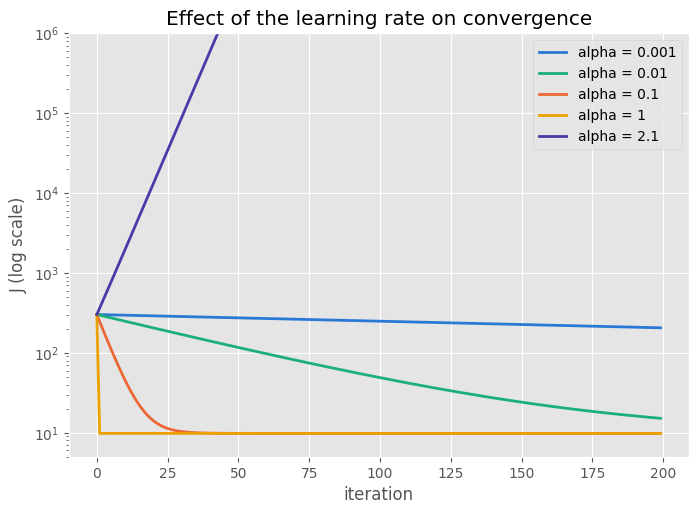

In [11]:
alphas = [0.001, 0.01, 0.1, 1.0, 2.1]
curve_colors = [blue, aqua, orange, '#eda100', '#4a3aa7']

plt.figure(figsize=(8, 5.5))
with np.errstate(over='ignore', invalid='ignore'):
    for a, c in zip(alphas, curve_colors):
        m = Linear_Regression(alpha=a, n_iter=200)
        m.fit(x_train_w_std, y_train)
        plt.plot(m.history, color=c, linewidth=2, label='alpha = %g' % a)
        print('alpha %-6g  iterations run %4d  final J %s' %
              (a, len(m.history), '%.4f' % m.history[-1] if np.isfinite(m.history[-1]) else 'diverged'))

plt.yscale('log')
plt.ylim(5, 1e6)   # the alpha = 2.1 curve leaves the top of the plot and keeps going
plt.xlabel('iteration')
plt.ylabel('J (log scale)')
plt.title('Effect of the learning rate on convergence')
plt.legend()
plt.show()

## Watching the line rotate into place

The parameters start at $w = 0, b = 0$, which is the flat line $\hat{y} = 0$ lying along the bottom
of the plot. Each iteration tilts and lifts it. The cell refits the model with `n_iter` set to 1, 5,
20 and 200 and draws the line each time over the same scatter, so the four snapshots show the
trajectory. Most of the movement happens in the first few steps, because the gradient is largest
when the fit is worst.

## The same descent, on the loss surface

The two panels below are the same run seen two ways. On the left the fitted line rotates and
lifts off its flat $\hat{y}=0$ start while $R^2$ climbs. On the right the same run is a single
point walking across the loss surface $J(w,b)$, with an arrow showing $-\nabla J$ at each step.

The arrow stays perpendicular to the contour it is crossing, which is what the gradient means -
it points along the steepest direction, so stepping against it is the fastest local decrease. The
arrow also shrinks as the walk proceeds and vanishes at the minimum, which is why the update

$$w \leftarrow w - \alpha\,\frac{\partial J}{\partial w}$$

comes to rest on its own without needing a separate stopping rule.

The surface is a bowl with exactly one bottom. That convexity is the reason gradient descent is
trustworthy here in a way it is not for the neural networks later in this repository: there are
no other minima to get caught in, so from any starting point and a small enough $\alpha$ it
arrives at the same answer the normal equation gives.

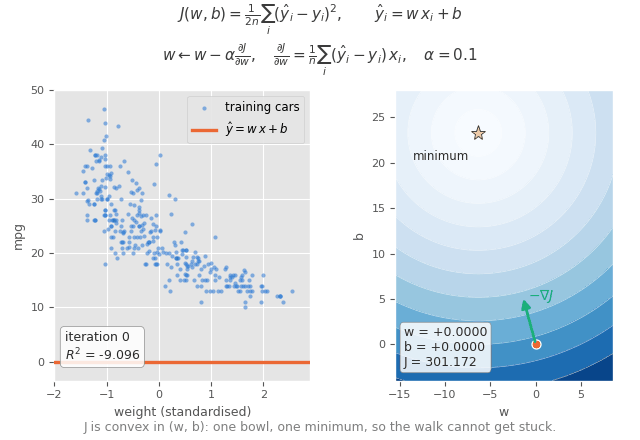

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/linreg_descent.gif')

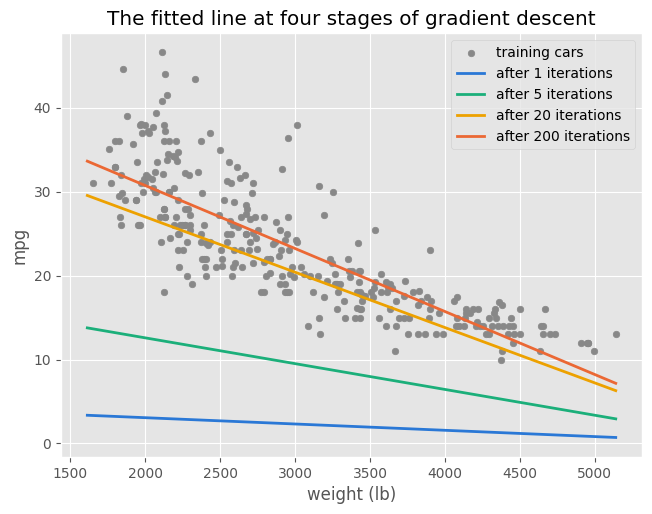

In [12]:
stages = [1, 5, 20, 200]
stage_colors = [blue, aqua, '#eda100', orange]

plt.figure(figsize=(7.5, 5.5))
plt.scatter(X_train_raw[:, w_col], y_train, s=22, color='#888888', label='training cars')

for it, c in zip(stages, stage_colors):
    m = Linear_Regression(alpha=0.1, n_iter=it)
    m.fit(x_train_w_std, y_train)
    wr = m.w[0] / sigma_w
    br = m.b - m.w[0] * mu_w / sigma_w
    plt.plot(grid, wr * grid + br, color=c, linewidth=2, label='after %d iterations' % it)

plt.xlabel('weight (lb)')
plt.ylabel('mpg')
plt.title('The fitted line at four stages of gradient descent')
plt.legend()
plt.show()

## Multiple regression, and why the features must be scaled

With all 7 features the model becomes $\hat{y} = \mathbf{w}^\top \mathbf{x} + b$ and the gradient
$\nabla_{\mathbf{w}} J = \tfrac{1}{n} X^\top (\hat{\mathbf{y}} - \mathbf{y})$ carries one entry per
column. That entry is proportional to the size of the column: `weight` sits around 3000 while
`cylinders` sits around 5.5, so the `weight` component of the gradient is roughly 500 times the
`cylinders` component, and every parameter is stepped by the same $\alpha$.

Geometrically the loss surface stops being a round bowl and becomes a long narrow valley. The
stability limit $\alpha < 2 / \lambda_{max}$ is set by the steepest direction, but progress along
the shallow directions goes at $\alpha \lambda_{min}$ per step. With a ratio of $10^6$ between
those, any $\alpha$ that does not immediately diverge moves the small-scale parameters by
essentially nothing.

Standardising each column removes the problem:

$$x_{ij}^{std} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

Every column then has mean 0 and standard deviation 1, the valley is close to round, and one $\alpha$
suits all directions. `mu` and `sigma` are computed on **`X_train_raw` only** and then applied to
the test rows. Using test statistics would let information from the held-out rows into the fitting
procedure and make the test score optimistic.

In [13]:
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)

X_train = (X_train_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

print('training means after scaling: ', np.round(X_train.mean(axis=0), 12))
print('training stds after scaling:  ', np.round(X_train.std(axis=0), 12))
print('test means after scaling:     ', np.round(X_test.mean(axis=0), 3))

training means after scaling:  [-0.  0.  0.  0.  0. -0. -0.]
training stds after scaling:   [1. 1. 1. 1. 1. 1. 1.]
test means after scaling:      [-0.057 -0.031 -0.06  -0.084 -0.032  0.11   0.029]


The next cell demonstrates the failure rather than asserting it, and shows both halves of the trap.
The raw columns are fitted at $\alpha = 0.05$, which is a perfectly ordinary learning rate, and then
at $\alpha = 10^{-7}$, small enough to survive. The standardised columns are fitted at
$\alpha = 0.05$. All three runs get 3000 iterations.

In [14]:
with np.errstate(over='ignore', invalid='ignore'):
    raw_big = Linear_Regression(alpha=0.05, n_iter=3000).fit(X_train_raw, y_train)

raw_small = Linear_Regression(alpha=1e-7, n_iter=3000).fit(X_train_raw, y_train)
std_fit = Linear_Regression(alpha=0.05, n_iter=3000).fit(X_train, y_train)

print('raw,    alpha 0.05  -> stopped after %4d iterations, J = %s' %
      (len(raw_big.history),
       '%.4f' % raw_big.history[-1] if np.isfinite(raw_big.history[-1]) else 'inf (diverged)'))
print('raw,    alpha 1e-7  -> ran %4d iterations, J = %8.4f, R2 = %7.4f, b = %.6f' %
      (len(raw_small.history), raw_small.history[-1],
       r_squared(y_train, raw_small.predict(X_train_raw)), raw_small.b))
print('scaled, alpha 0.05  -> ran %4d iterations, J = %8.4f, R2 = %7.4f, b = %.6f' %
      (len(std_fit.history), std_fit.history[-1],
       r_squared(y_train, std_fit.predict(X_train)), std_fit.b))
print()
print('mean of the training targets: %.4f mpg' % y_train.mean())

raw,    alpha 0.05  -> stopped after   28 iterations, J = inf (diverged)
raw,    alpha 1e-7  -> ran 3000 iterations, J =  38.7711, R2 = -0.2995, b = 0.000765
scaled, alpha 0.05  -> ran 3000 iterations, J =   5.5697, R2 =  0.8133, b = 23.295527

mean of the training targets: 23.2955 mpg


Both failure modes show up. At $\alpha = 0.05$ the raw fit diverges to infinity within a few dozen
iterations and the loop stops. At $\alpha = 10^{-7}$ it survives but crawls: after 3000 iterations
the intercept is still at 0.0008 when it needs to reach 23.3, and the training $R^2$ is negative, so
the model is worse than predicting the mean. There is no learning rate between those that fixes
both, because the problem is the ratio between the column scales, not the value of $\alpha$.

The standardised fit at the same $\alpha = 0.05$ reaches $R^2 = 0.81$ and its intercept sits exactly
on the training mean, which is where it belongs when every feature has mean zero.

Now the real fit: all 7 standardised features, $\alpha = 0.1$, 20000 iterations. That is far more
iterations than the loss curve needs, and the reason is the normal-equation comparison two sections
below, which is only meaningful if gradient descent has been run to tight convergence rather than
merely to a good-looking loss curve.

In [15]:
multi = Linear_Regression(alpha=0.1, n_iter=20000)
multi.fit(X_train, y_train)

pred_train_m = multi.predict(X_train)
pred_test_m = multi.predict(X_test)

print('intercept b = %.4f' % multi.b)
for name, coef in zip(feature_names, multi.w):
    print('  %-14s %8.4f' % (name, coef))

intercept b = 23.2955
  displacement     1.9311
  cylinders       -0.7798
  horsepower      -1.2797
  weight          -4.9155
  acceleration    -0.2426
  model_year       2.8007
  origin           1.2424


The comparison that matters is against the weight-only model. Both are scored on the same rows.
`adjusted_r_squared` is passed the number of features so the 7-feature model is charged for them.

In [16]:
print('                       simple (weight)      multiple (7 features)')
print('train R2            %14.4f %22.4f' % (r_squared(y_train, pred_train_s), r_squared(y_train, pred_train_m)))
print('test  R2            %14.4f %22.4f' % (r_squared(y_test, pred_test_s), r_squared(y_test, pred_test_m)))
print('train adjusted R2   %14.4f %22.4f' % (adjusted_r_squared(y_train, pred_train_s, 1),
                                             adjusted_r_squared(y_train, pred_train_m, 7)))
print('train RMSE mpg      %14.4f %22.4f' % (rmse(y_train, pred_train_s), rmse(y_train, pred_train_m)))
print('test  RMSE mpg      %14.4f %22.4f' % (rmse(y_test, pred_test_s), rmse(y_test, pred_test_m)))
print('test  MAE  mpg      %14.4f %22.4f' % (mae(y_test, pred_test_s), mae(y_test, pred_test_m)))

                       simple (weight)      multiple (7 features)
train R2                    0.6717                 0.8133
test  R2                    0.7657                 0.8429
train adjusted R2           0.6707                 0.8090
train RMSE mpg              4.4256                 3.3376
test  RMSE mpg              3.8928                 3.1873
test  MAE  mpg              2.9068                 2.3587


## The normal equation

Gradient descent is not the only option. Because $J$ is convex and quadratic, the minimum is exactly
where the gradient is zero, and that condition can be solved in closed form. Fold the intercept into
the weights by adding a column of ones to $X$, so $\theta = [b, w_1, \dots, w_D]^\top$ and
$\hat{\mathbf{y}} = X\theta$. Then

$$J(\theta) = \frac{1}{2n} \lVert X\theta - \mathbf{y} \rVert^2
\qquad
\nabla_{\theta} J = \frac{1}{n} X^\top \left( X\theta - \mathbf{y} \right)$$

Setting that to zero gives the normal equations $X^\top X \theta = X^\top \mathbf{y}$, and hence

$$\theta = \left( X^\top X \right)^{-1} X^\top \mathbf{y}$$

The code uses `np.linalg.solve(XtX, Xty)` rather than `np.linalg.inv(XtX).dot(Xty)`. The two are
mathematically identical, but forming the explicit inverse squares the condition number and loses
precision, whereas `solve` factorises and back-substitutes. The inverse is computed alongside it
here only to show the two routes land in the same place.

If this is exact and immediate, why iterate at all? Cost. Building $X^\top X$ takes $O(nD^2)$ and
solving it takes $O(D^3)$. With $D = 7$ that is nothing. With $D$ in the hundreds of thousands, as
in text or genomics problems, $D^3$ is unreachable and $X^\top X$ would not fit in memory, while
gradient descent only ever needs matrix-vector products and can work on mini-batches. The closed
form is the right tool at this size and the wrong tool at that one.

In [17]:
def normal_equation(X, y):
    n = len(X)
    Xb = np.hstack([np.ones((n, 1)), X])   # column of ones for the intercept
    XtX = Xb.T.dot(Xb)
    Xty = Xb.T.dot(y)
    return np.linalg.solve(XtX, Xty)


theta = normal_equation(X_train, y_train)

# the explicit-inverse route, for comparison
Xb = np.hstack([np.ones((len(X_train), 1)), X_train])
theta_inv = np.linalg.inv(Xb.T.dot(Xb)).dot(Xb.T.dot(y_train))

print('solve vs inv, largest difference: %.3e' % np.max(np.abs(theta - theta_inv)))
print('condition number of X^T X: %.1f' % np.linalg.cond(Xb.T.dot(Xb)))

solve vs inv, largest difference: 1.399e-14
condition number of X^T X: 134.0


Now the check. `theta_gd` stacks the gradient descent intercept and weights into the same layout as
`theta`, and the two vectors are printed side by side with their differences.

In [18]:
theta_gd = np.concatenate([[multi.b], multi.w])
names = ['intercept'] + feature_names

print('%-14s %12s %12s %14s' % ('', 'grad descent', 'normal eq', 'difference'))
for name, a, b in zip(names, theta_gd, theta):
    print('%-14s %12.6f %12.6f %14.2e' % (name, a, b, a - b))

max_diff = np.max(np.abs(theta_gd - theta))
print()
print('largest absolute difference: %.3e' % max_diff)

pred_train_ne = np.hstack([np.ones((len(X_train), 1)), X_train]).dot(theta)
pred_test_ne = np.hstack([np.ones((len(X_test), 1)), X_test]).dot(theta)
print('train R2  gradient descent %.8f   normal equation %.8f' %
      (r_squared(y_train, pred_train_m), r_squared(y_train, pred_train_ne)))
print('test  R2  gradient descent %.8f   normal equation %.8f' %
      (r_squared(y_test, pred_test_m), r_squared(y_test, pred_test_ne)))

               grad descent    normal eq     difference
intercept         23.295527    23.295527      -1.42e-14
displacement       1.931069     1.931069      -4.29e-14
cylinders         -0.779825    -0.779825      -4.44e-14
horsepower        -1.279672    -1.279672       1.91e-14
weight            -4.915516    -4.915516       5.42e-14
acceleration      -0.242648    -0.242648      -7.30e-15
model_year         2.800670     2.800670      -2.22e-15
origin             1.242387     1.242387      -1.53e-14

largest absolute difference: 5.418e-14
train R2  gradient descent 0.81328912   normal equation 0.81328912
test  R2  gradient descent 0.84293402   normal equation 0.84293402


Two entirely different procedures, an iterative walk downhill and a single linear solve, arrive at
the same coefficients. Convexity is what guarantees this: there is only one place the gradient
vanishes, so any method that gets there gets to the same point.

## Predicted against actual

The standard diagnostic plot. Each test car is one point, its true mpg on the x-axis and the model's
prediction on the y-axis. A perfect model would put every point on the dashed $y = x$ line, so the
vertical distance from that line is the error. $R^2$ is printed in the corner.

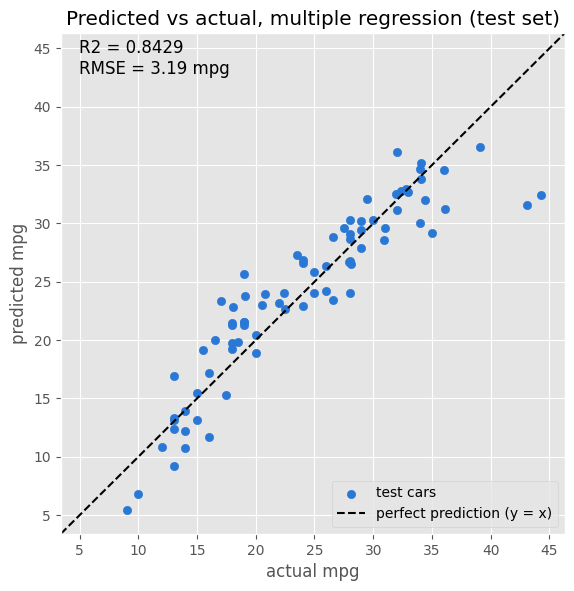

In [19]:
lo = min(y_test.min(), pred_test_m.min()) - 2
hi = max(y_test.max(), pred_test_m.max()) + 2

plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, pred_test_m, s=35, color=blue, label='test cars')
plt.plot([lo, hi], [lo, hi], '--', color='k', linewidth=1.5, label='perfect prediction (y = x)')
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.xlabel('actual mpg')
plt.ylabel('predicted mpg')
plt.title('Predicted vs actual, multiple regression (test set)')
plt.text(lo + 1.5, hi - 3.5, 'R2 = %.4f\nRMSE = %.2f mpg' % (r_squared(y_test, pred_test_m), rmse(y_test, pred_test_m)),
         fontsize=12)
plt.legend(loc='lower right')
plt.show()

## Residuals

The residual is $y_i - \hat{y}_i$, plotted against the prediction. If the linear model captured the
structure, the residuals would be a shapeless band around zero with no relationship to the predicted
value. Any pattern left in this plot is signal the model failed to use.

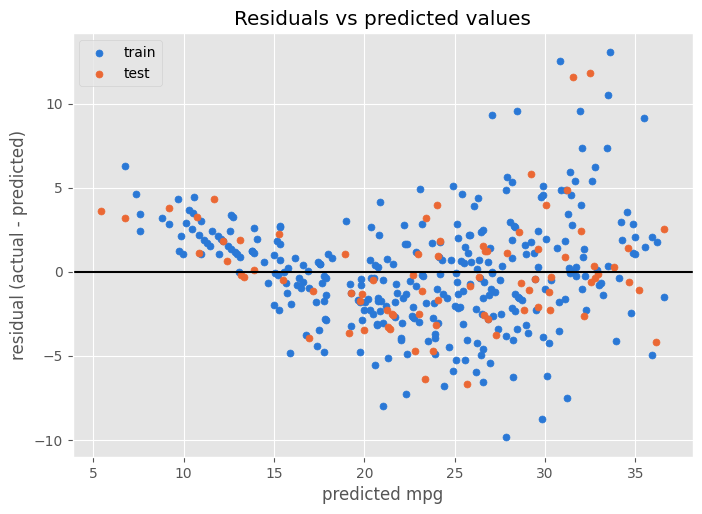

predicted   6.7 to  20.6 mpg : mean residual +0.333  (103 cars)
predicted  20.6 to  26.8 mpg : mean residual -1.188  (103 cars)
predicted  26.8 to  36.6 mpg : mean residual +0.823  (107 cars)


In [20]:
res_train = y_train - pred_train_m
res_test = y_test - pred_test_m

plt.figure(figsize=(8, 5.5))
plt.scatter(pred_train_m, res_train, s=25, color=blue, label='train')
plt.scatter(pred_test_m, res_test, s=25, color=orange, label='test')
plt.axhline(0, color='k', linewidth=1.5)
plt.xlabel('predicted mpg')
plt.ylabel('residual (actual - predicted)')
plt.title('Residuals vs predicted values')
plt.legend()
plt.show()

# average residual in three bands of the prediction range, to check for curvature
edges = np.percentile(pred_train_m, [0, 33, 66, 100])
for k in range(3):
    sel = (pred_train_m >= edges[k]) & (pred_train_m <= edges[k + 1])
    print('predicted %5.1f to %5.1f mpg : mean residual %+6.3f  (%d cars)' %
          (edges[k], edges[k + 1], res_train[sel].mean(), sel.sum()))

This one is not clean, and the printed band averages confirm what the eye sees. The residuals are
positive on average at both ends of the prediction range and negative in the middle, which is a
U shape rather than a flat band. The model under-predicts the most economical cars and slightly
under-predicts the least economical ones while over-predicting the middle.

That is the signature of a relationship that is not linear. Fuel consumption per mile is closer to
proportional to weight, so mpg, being its reciprocal, bends: the curve is steep among light cars and
flattens among heavy ones, and a straight line cannot follow both. The spread also widens towards
high predicted mpg, so the errors are not of constant size either. Fitting $\log(\text{mpg})$, or
adding $1/\text{weight}$ as a feature, would address this. Neither is done here, and the honest
summary is that the linear model leaves real structure on the table.

## The coefficients

Because every feature was standardised to the same scale, the weights are directly comparable: each
is the change in predicted mpg for a one-standard-deviation increase in that feature, with the
others held fixed. On raw columns this comparison would be meaningless, since a coefficient on
`weight` is per pound and a coefficient on `cylinders` is per cylinder.

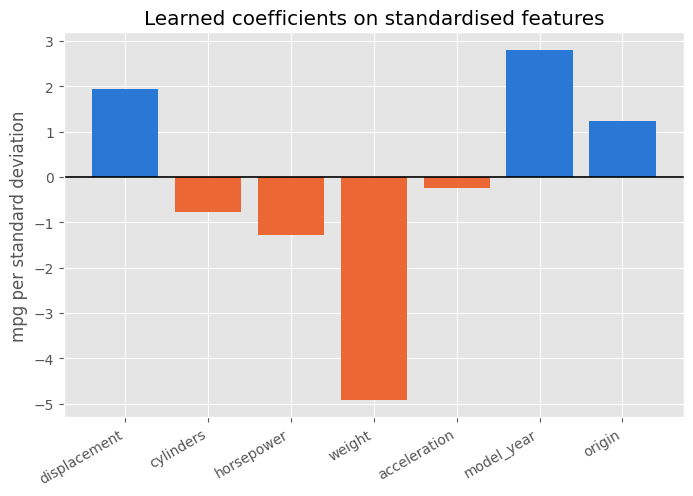

In [21]:
sign_colors = [blue if c >= 0 else orange for c in multi.w]

plt.figure(figsize=(8, 5))
plt.bar(range(len(multi.w)), multi.w, color=sign_colors)
plt.axhline(0, color='k', linewidth=1.2)
plt.xticks(range(len(feature_names)), feature_names, rotation=30, ha='right')
plt.ylabel('mpg per standard deviation')
plt.title('Learned coefficients on standardised features')
plt.show()

`model_year` is the largest positive term, so newer cars are more economical once size is accounted
for, and `weight` is the largest negative one. `displacement` carries a small positive coefficient
even though bigger engines plainly use more fuel. That is not a contradiction, it is collinearity:
`displacement`, `cylinders`, `weight` and `horsepower` all measure roughly the same thing and are
strongly correlated, so least squares can shuffle influence between them and individual signs stop
being interpretable in isolation. Only their combined effect is pinned down.

## Adding a column of noise

The claim above was that training $R^2$ never falls when a feature is added, however worthless.
Here it is tested directly. `np.random.RandomState(7)` generates columns of standard normal values
with no relationship whatsoever to fuel economy, they are appended to both the train and test
matrices, and the model is refitted. The loop does this with 1, 5 and 20 noise columns, since one
column moves the numbers so little that the trend is easier to see across several.

The normal equation is used rather than gradient descent, because the effect is small and has to be
measured against the exact least-squares optimum rather than a nearly-converged approximation.

In [22]:
def predict_theta(X, theta):
    return np.hstack([np.ones((len(X), 1)), X]).dot(theta)


base_r2_train = r_squared(y_train, pred_train_ne)
base_r2_test = r_squared(y_test, pred_test_ne)
base_adj = adjusted_r_squared(y_train, pred_train_ne, 7)

print('           train R2              train adjusted R2         test R2')
print('7 real  %10.6f            %10.6f            %10.6f' % (base_r2_train, base_adj, base_r2_test))

for k in [1, 5, 20]:
    noise_rng = np.random.RandomState(7)
    noise_train = noise_rng.randn(len(X_train), k)
    noise_test = noise_rng.randn(len(X_test), k)

    Xn_train = np.hstack([X_train, noise_train])
    Xn_test = np.hstack([X_test, noise_test])

    theta_noise = normal_equation(Xn_train, y_train)
    p_tr = predict_theta(Xn_train, theta_noise)
    p_te = predict_theta(Xn_test, theta_noise)

    r2_tr = r_squared(y_train, p_tr)
    adj_tr = adjusted_r_squared(y_train, p_tr, 7 + k)
    r2_te = r_squared(y_test, p_te)

    print('+%2d fake %9.6f (%+.6f) %10.6f (%+.6f) %10.6f (%+.6f)' %
          (k, r2_tr, r2_tr - base_r2_train, adj_tr, adj_tr - base_adj, r2_te, r2_te - base_r2_test))

# what weight did the single noise column get?
noise_rng = np.random.RandomState(7)
one_noise = noise_rng.randn(len(X_train), 1)
theta_one = normal_equation(np.hstack([X_train, one_noise]), y_train)
print()
print('correlation of the single noise column with mpg: %+.4f' % np.corrcoef(one_noise.ravel(), y_train)[0, 1])
print('weight least squares gave it:                    %+.4f' % theta_one[-1])

           train R2              train adjusted R2         test R2
7 real    0.813289              0.809004              0.842934
+ 1 fake  0.813406 (+0.000117)   0.808495 (-0.000508)   0.843496 (+0.000562)
+ 5 fake  0.816171 (+0.002882)   0.808818 (-0.000186)   0.845577 (+0.002643)
+20 fake  0.818811 (+0.005522)   0.801646 (-0.007358)   0.837387 (-0.005547)

correlation of the single noise column with mpg: +0.0387
weight least squares gave it:                    +0.0874


Training $R^2$ rises every time, exactly as predicted, and it never once falls. The noise columns
are uncorrelated with mpg by construction, and the single one has a sample correlation of only
+0.039, yet least squares still gives it a weight of +0.087. A random vector in 313-dimensional
space always has some accidental overlap with the residual, and least squares takes whatever it can
get.

Adjusted $R^2$ is the honest counterweight: it falls in all three cases, and falls hardest at 20
columns where the penalty $\tfrac{n-1}{n-D-1}$ has grown enough to dominate.

Test $R^2$ deserves a caveat rather than a clean story. At 20 noise columns it drops by 0.0055, as
expected. At 1 and 5 columns it actually creeps *up*, by 0.0006 and 0.0026. That is not evidence
that noise helps. A 79-row test set is itself a small sample, and shifts of that size are well
inside the range that changing the random split would produce. The point stands that training $R^2$
alone cannot compare models with different feature counts, and it is worth noticing that a single
held-out set is a noisy instrument too, which is the argument for cross-validation.

## Summary

- Linear regression fits $\hat{y} = \mathbf{w}^\top\mathbf{x} + b$ by minimising the mean squared
  error, which is convex in the parameters, so there is one global minimum and no local ones.
- Gradient descent reaches it by repeatedly stepping against
  $\nabla_{\mathbf{w}} J = \tfrac{1}{n}X^\top(\hat{\mathbf{y}} - \mathbf{y})$, and $\alpha$ must sit
  below $2/\lambda_{max}$ or the run diverges outright.
- Standardising the features is not optional here. Raw `weight` and `cylinders` differ by three
  orders of magnitude and no single learning rate works for both.
- The normal equation $\theta = (X^\top X)^{-1}X^\top\mathbf{y}$ solves the same problem exactly and
  agrees with the iterative answer, which validates the implementation. It stops being practical
  once $D$ is large, because of the $O(D^3)$ solve.
- $R^2$ is the share of the variance explained, is unitless, can go negative on held-out data, and
  never falls on training data when a feature is added. RMSE and MAE report the error in mpg.
- The residual plot shows genuine curvature, so the linear model is a reasonable but incomplete
  description of this data.